In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For Modelling 
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge, Lasso
from sklearn.model_selection import RandomizedSearchCV
import warnings
warnings.filterwarnings("ignore")

In [3]:
import os 
folder_path = "data\\"
file_name = "laptop_price_edited.csv"
full_path = os.path.join(folder_path, file_name)
df = pd.read_csv(full_path)


In [4]:
df.head()

,Company,TypeName,Inches,Cpu,Ram,Memory,OpSys,Weight,Price_euros,Screen_width,Screen_height
0,Apple,Ultrabook,13.3,Intel Core i5,8.0,128GB SSD,macOS,1.37,1339.69,2560.0,1600.0
1,HP,Notebook,15.6,Intel Core i5,8.0,256GB SSD,No OS,1.86,575.00,1920.0,1080.0
2,Apple,Ultrabook,15.4,Intel Core i7,16.0,512GB SSD,macOS,1.83,2537.45,2880.0,1800.0
3,Apple,Ultrabook,13.3,Intel Core i5,8.0,256GB SSD,macOS,1.37,1803.60,2560.0,1600.0
4,Asus,Ultrabook,14.0,Intel Core i7,16.0,512GB SSD,Windows 10,1.30,1495.00,1920.0,1080.0


In [5]:
X= df.drop(columns=["Price_euros"])

In [6]:
y = df["Price_euros"]

In [7]:
catergorical_features = X.select_dtypes(include="object").columns
numerical_features = X.select_dtypes(exclude="object").columns

In [8]:
from sklearn.preprocessing import OneHotEncoder , StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
catergorical_transformer = OneHotEncoder()
preprocess = ColumnTransformer(
    [
    ("OneHotEncoder", catergorical_transformer,catergorical_features),
    ("StandardScaler", numeric_transformer, numerical_features)
    ]
)

In [9]:
X = preprocess.fit_transform(X)

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
# Create an evaluate model function 

def evaluate_model(true, predicted):
    mae = mean_absolute_error(true,predicted)
    mse = mean_squared_error(true,predicted)
    r2 = r2_score(true, predicted)
    return mae, mse ,r2

In [13]:
models = {
    "LinearRegression":LinearRegression(),
    "RandomForestRegressor":RandomForestRegressor(),
    "KNeighborsRegressor": KNeighborsRegressor(),
    "DecisionTreeRegressor":DecisionTreeRegressor(),
    "Ridge":Ridge(),
    "Lasso":Lasso()
}

model_list = []
r2_list_test = []
r2_list_train = []
mse_list_test = []
mse_list_train = []
mae_list_test = []
mae_list_train = []


In [14]:
for i in range(len(list(models))):
    print(list(models.keys())[i])
    model = list(models.values())[i]
    model.fit(X_train,y_train)
    
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    # Evaluate Model
    mae_train, mse_train, r2_train= evaluate_model(y_train,y_train_pred)
    mae_test, mse_test, r2_test= evaluate_model(y_test,y_test_pred)
    
    
    model_list.append(list(models.keys())[i])


    r2_list_test.append(r2_test)
    r2_list_train.append(r2_train)

    mae_list_test.append(mae_test)
    mse_list_test.append(mse_test)

    mae_list_train.append(mae_train)
    mse_list_train.append(mse_train)

    print("Prediction Accuracy for training data")
    print(f"Mean square error {mse_train}")
    print(f"Mean absolute error {mae_train}")
    print(f"r2_score {r2_train}")
    print("-"*20)
    print("Prediction Accuracy for test data")
    print(f"Mean square error {mse_test}")
    print(f"Mean absolute error {mae_test}")
    print(f"r2_score {r2_test}")
    print("="*30)
    print("\n")
    

LinearRegression
Prediction Accuracy for training data
Mean square error 95072.66498217624
Mean absolute error 222.51393559646027
r2_score 0.7479994864824182
--------------------
Prediction Accuracy for test data
Mean square error 92388.1792538012
Mean absolute error 218.00276765485626
r2_score 0.772003462819337


RandomForestRegressor
Prediction Accuracy for training data
Mean square error 13538.697835081692
Mean absolute error 76.51011136942999
r2_score 0.964114198256254
--------------------
Prediction Accuracy for test data
Mean square error 89430.91782974658
Mean absolute error 196.88867517529488
r2_score 0.7793014241999825


KNeighborsRegressor
Prediction Accuracy for training data
Mean square error 67237.93327937787
Mean absolute error 173.57819124423963
r2_score 0.8217784920887543
--------------------
Prediction Accuracy for test data
Mean square error 94268.96916348624
Mean absolute error 210.64996330275227
r2_score 0.7673620293585203


DecisionTreeRegressor
Prediction Accuracy

In [15]:
pd.DataFrame(list(zip(model_list, r2_list_test,r2_list_train,mse_list_test,mse_list_train,mae_list_test,mae_list_train)), 
             columns=["Model Name",'R2_Score_test',"R2_Score_Train", "mean_squared_error test","mean_squared_error train" ,
                      "mean_absolute_error test","mean_absolute_error train"])

,Model Name,R2_Score_test,R2_Score_Train,mean_squared_error test,mean_squared_error train,mean_absolute_error test,mean_absolute_error train
0,LinearRegression,0.772003,0.747999,92388.179254,95072.664982,218.002768,222.513936
1,RandomForestRegressor,0.779301,0.964114,89430.917830,13538.697835,196.888675,76.510111
2,KNeighborsRegressor,0.767362,0.821778,94268.969163,67237.933279,210.649963,173.578191
3,DecisionTreeRegressor,0.690439,0.992292,125439.693190,2908.090482,220.786002,15.271411
4,Ridge,0.767657,0.747111,94149.554741,95408.015613,218.293156,223.398961
5,Lasso,0.759485,0.742813,97460.938169,97029.410343,222.005218,225.676927


### Random Forest Regression

In [16]:
rfr = RandomForestRegressor()
rfr.fit(X_train,y_train)
y_pred= rfr.predict(X_test)
score =r2_score(y_test,y_pred)*100
print(score)


78.55515751482957


### Plot y_pred and y_test

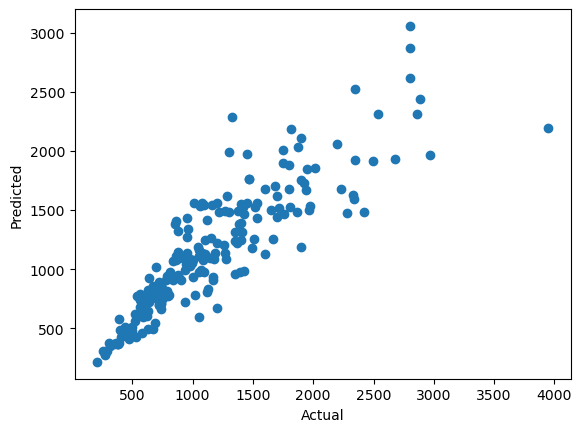

In [17]:
plt.scatter(y_test,y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

In [18]:
numerical_features,catergorical_features

(Index(['Inches', 'Ram', 'Weight', 'Screen_width', 'Screen_height'], dtype='object'),
 Index(['Company', 'TypeName', 'Cpu', 'Memory', 'OpSys'], dtype='object'))